In [ ]:
# ============================================================
# 🔹 STEP 1: Import libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.utils import check_random_state
from google.colab import files

# ============================================================
# 🔹 STEP 2: Upload the BankChurners.csv file
# ============================================================

print("📂 Please upload your BankChurners.csv file:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]  # get uploaded file name
df = pd.read_csv(filename)
print(f"\n✅ File '{filename}' uploaded successfully!")
print("Shape:", df.shape)
df.head()


📂 Please upload your BankChurners.csv file:


Saving BankChurners.csv to BankChurners.csv

✅ File 'BankChurners.csv' uploaded successfully!
Shape: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [ ]:
# ============================================================
# 🔹 STEP 3: Define Basic K-Means
# ============================================================

class BasicKMeans:
    def __init__(self, n_clusters=4, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = np.random.RandomState(random_state)

    def _init_centroids(self, X):
        indices = self.random_state.choice(len(X), self.n_clusters, replace=False)
        return X[indices]

    def fit(self, X):
        X = np.asarray(X)
        centroids = self._init_centroids(X)

        for _ in range(self.max_iter):
            distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
            labels = np.argmin(distances, axis=1)
            new_centroids = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k)
                else centroids[k] for k in range(self.n_clusters)
            ])
            shift = np.linalg.norm(new_centroids - centroids)
            centroids = new_centroids
            if shift < self.tol:
                break

        self.cluster_centers_ = centroids
        self.labels_ = np.argmin(
            np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2), axis=1
        )
        self.inertia_ = np.sum((X - centroids[self.labels_]) ** 2)
        return self

In [ ]:
# ============================================================
# 🔹 STEP 4: Define Improved (Trimmed) K-Means
# ============================================================

class ImprovedKMeans:
    def __init__(self, n_clusters=4, n_init=10, max_iter=500, tol=1e-5,
                 alpha=0.05, random_state=None):
        self.n_clusters = n_clusters
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol
        self.alpha = alpha
        self.random_state = check_random_state(random_state)

    def _kmeans_plus_plus_init(self, X, k):
        rng = self.random_state
        n_samples = len(X)
        centers = [X[rng.randint(0, n_samples)]]
        for _ in range(1, k):
            dist_sq = np.min(
                np.linalg.norm(X[:, None] - np.array(centers)[None, :], axis=2) ** 2,
                axis=1,
            )
            probs = dist_sq / np.sum(dist_sq)
            cumulative = np.cumsum(probs)
            r = rng.rand()
            next_center = X[np.searchsorted(cumulative, r)]
            centers.append(next_center)
        return np.array(centers)

    def _trimmed_update(self, X, labels, centers):
        n = len(X)
        dists = np.linalg.norm(X - centers[labels], axis=1)
        keep = np.argsort(dists)[: int((1 - self.alpha) * n)]
        new_centers = np.zeros_like(centers)
        for k in range(self.n_clusters):
            members = X[keep][labels[keep] == k]
            if len(members) > 0:
                new_centers[k] = members.mean(axis=0)
            else:
                new_centers[k] = centers[k]
        return new_centers

    def _single_fit(self, X):
        best_inertia = np.inf
        best_centers = None
        best_labels = None

        for _ in range(self.n_init):
            centers = self._kmeans_plus_plus_init(X, self.n_clusters)
            for _ in range(self.max_iter):
                distances = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
                labels = np.argmin(distances, axis=1)
                new_centers = self._trimmed_update(X, labels, centers)
                shift = np.linalg.norm(new_centers - centers)
                centers = new_centers
                if shift < self.tol:
                    break
            inertia = np.sum((X - centers[labels]) ** 2)
            if inertia < best_inertia:
                best_inertia = inertia
                best_centers = centers
                best_labels = labels
        return best_centers, best_labels, best_inertia

    def fit(self, X):
        X = np.asarray(X)
        self.cluster_centers_, self.labels_, self.inertia_ = self._single_fit(X)
        return self

In [ ]:
# ============================================================
# 🔹 STEP 5: Preprocess and Run Both Models + Show Cluster Distribution
# ============================================================

# Choose numeric features for clustering
features = [
    "Customer_Age", "Dependent_count", "Months_on_book",
    "Total_Relationship_Count", "Months_Inactive_12_mon",
    "Contacts_Count_12_mon", "Credit_Limit", "Total_Revolving_Bal",
    "Avg_Open_To_Buy", "Total_Amt_Chng_Q4_Q1", "Total_Trans_Amt",
    "Total_Trans_Ct", "Total_Ct_Chng_Q4_Q1", "Avg_Utilization_Ratio"
]

# Extract feature matrix
X = df[features].values

# Scale for equal weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit both models
basic = BasicKMeans(n_clusters=5, random_state=42).fit(X_scaled)
improved = ImprovedKMeans(n_clusters=5, n_init=10, alpha=0.05, random_state=42).fit(X_scaled)

# Evaluate results
sil_basic = silhouette_score(X_scaled, basic.labels_)
sil_improved = silhouette_score(X_scaled, improved.labels_)

print("\n=== BANK CHURNERS CLUSTERING COMPARISON ===")
print(f"Samples: {len(X)}")
print(f"Basic K-Means -> Inertia: {basic.inertia_:.2f}, Silhouette: {sil_basic:.4f}")
print(f"Improved K-Means -> Inertia: {improved.inertia_:.2f}, Silhouette: {sil_improved:.4f}")

# Add cluster labels to DataFrame
df["Basic_Cluster"] = basic.labels_
df["Improved_Cluster"] = improved.labels_

# ============================================================
# 🔹 SHOW CLUSTER DISTRIBUTIONS FOR BOTH MODELS
# ============================================================

print("\n=== CLUSTER DISTRIBUTIONS ===")
print("Basic K-Means:")
print(df["Basic_Cluster"].value_counts().sort_index())

print("\nImproved K-Means:")
print(df["Improved_Cluster"].value_counts().sort_index())


=== BANK CHURNERS CLUSTERING COMPARISON ===
Samples: 10127
Basic K-Means -> Inertia: 96081.00, Silhouette: 0.1272
Improved K-Means -> Inertia: 96246.12, Silhouette: 0.1275

=== CLUSTER DISTRIBUTIONS ===
Basic K-Means:
Basic_Cluster
0     991
1    2056
2    3051
3    1325
4    2704
Name: count, dtype: int64

Improved K-Means:
Improved_Cluster
0     988
1    1326
2    3070
3    2015
4    2728
Name: count, dtype: int64


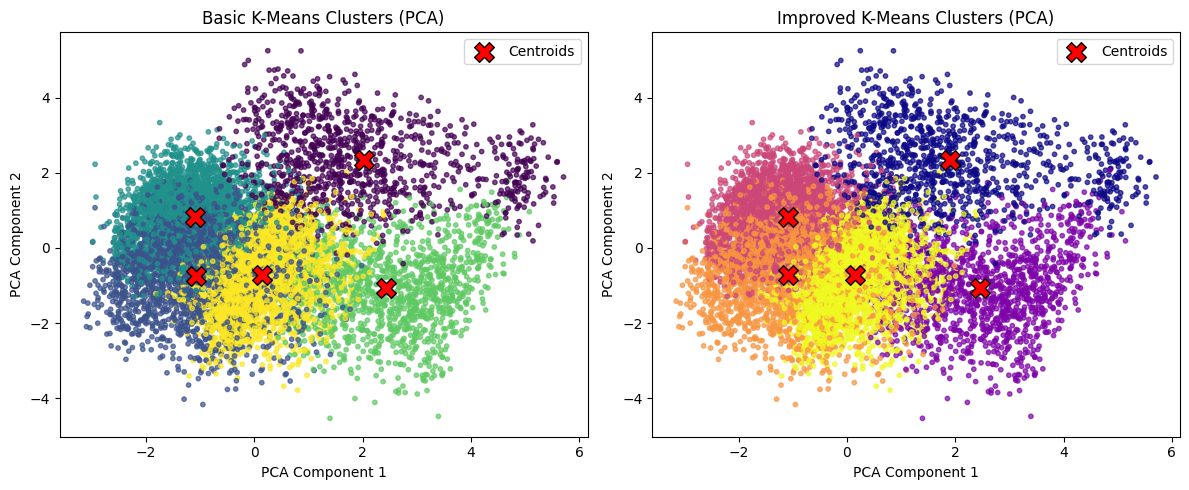

In [ ]:
# ============================================================
# 🔹 STEP 6: PCA Visualization (2D) with Centroids
# ============================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

# --- Basic K-Means plot ---
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=basic.labels_, cmap="viridis", s=10, alpha=0.7)
centroids_pca_basic = pca.transform(basic.cluster_centers_)
plt.scatter(centroids_pca_basic[:, 0], centroids_pca_basic[:, 1],
            c="red", marker="X", s=200, edgecolor="black", label="Centroids")
plt.title("Basic K-Means Clusters (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()

# --- Improved K-Means plot ---
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=improved.labels_, cmap="plasma", s=10, alpha=0.7)
centroids_pca_improved = pca.transform(improved.cluster_centers_)
plt.scatter(centroids_pca_improved[:, 0], centroids_pca_improved[:, 1],
            c="red", marker="X", s=200, edgecolor="black", label="Centroids")
plt.title("Improved K-Means Clusters (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()

plt.tight_layout()
plt.show()

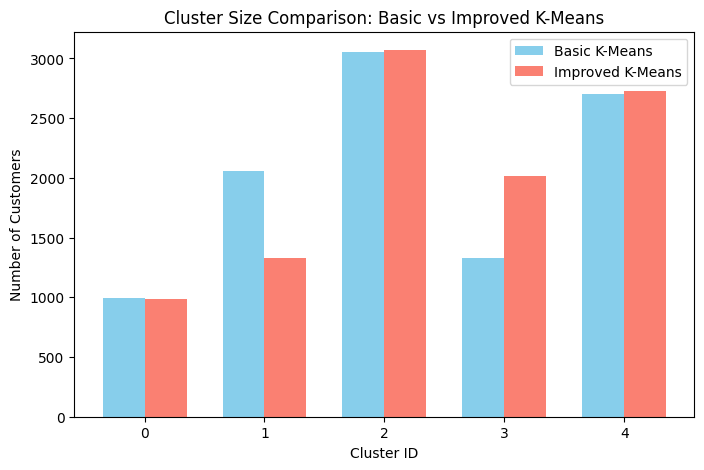

In [ ]:
 # ============================================================
# 🔹 Cluster Size Comparison (Bar Chart)
# ============================================================
import seaborn as sns

basic_counts = df["Basic_Cluster"].value_counts().sort_index()
improved_counts = df["Improved_Cluster"].value_counts().sort_index()

cluster_ids = range(len(basic_counts))

plt.figure(figsize=(8,5))
width = 0.35

plt.bar(np.array(cluster_ids)-width/2, basic_counts, width=width, label='Basic K-Means', color='skyblue')
plt.bar(np.array(cluster_ids)+width/2, improved_counts, width=width, label='Improved K-Means', color='salmon')

plt.title("Cluster Size Comparison: Basic vs Improved K-Means")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()